# PCA

## Datasett og klargjøring

Bildene ligger i `vehicle-type-detection/r7bthvstxw-1`, sortert etter biltype.
Vi gjør dem om til gråtonebilder på 64 × 64 piksler og skalerer pikselverdiene til [0, 1], som forberedelse til PCA.
Kjør cellene fra toppen. Hvis pakker mangler, kjør `%pip install pillow numpy matplotlib` i en egen celle.


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


In [20]:
# Kjør notebooken med Assignment2 som arbeidsmappe.
data_dir = Path("vehicle-type-detection/r7bthvstxw-1")
image_size = (64, 64)
image_paths = sorted(data_dir.rglob("*.jpg"))

if not image_paths:
    raise FileNotFoundError(f"Fant ingen bilder i {data_dir.resolve()}")

images = []
labels = []

for path in image_paths:
    with Image.open(path) as image:
        image = image.convert("L")  # L betyr gråtoner.
        image = image.resize(image_size)
        images.append(np.asarray(image, dtype=np.float32) / 255.0)
    labels.append(path.parent.name)

images = np.array(images)
labels = np.array(labels)

print(f"Lastet inn {len(images)} bilder.")
print(f"Form på bildedata: {images.shape}")
for label in np.unique(labels):
    print(f"{label}: {np.sum(labels == label)} bilder")


Lastet inn 1310 bilder.
Form på bildedata: (1310, 64, 64)
hatchback: 181 bilder
motorcycle: 122 bilder
pickup: 478 bilder
sedan: 400 bilder
suv: 129 bilder


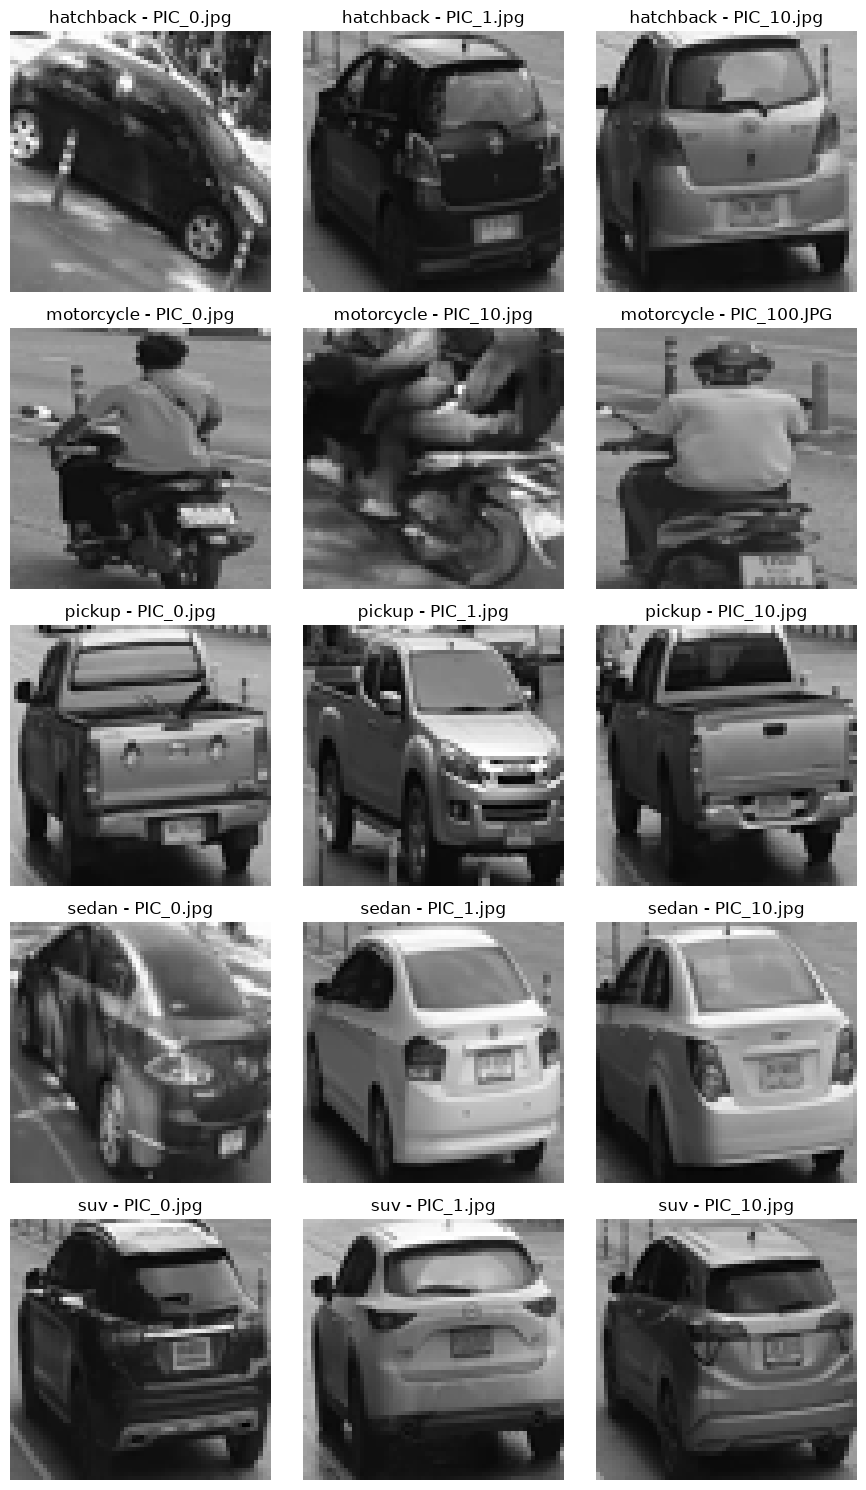

In [21]:
# Vis tre bilder fra hver biltype.
classes = np.unique(labels)
fig, axes = plt.subplots(len(classes), 3, figsize=(9, 3 * len(classes)), squeeze=False)

for row, label in enumerate(classes):
    indices = np.where(labels == label)[0][:3]
    for ax in axes[row]:
        ax.axis("off")
    for col, index in enumerate(indices):
        axes[row, col].imshow(images[index], cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(f"{label} - {image_paths[index].name}")

plt.tight_layout()
plt.show()


## PCA Implementation

Bildene flates ut til en matrise med ett bilde per rad og en kolonne per pikselposisjon. Hvert bilde gir dermed 4096 verdier.

Vi sentrerer dataene ved å trekke fra gjennomsnittet for hver pikselposisjon. Deretter beregner vi kovariansmatrisen og finner egenverdiene og egenvektorene.
Egenvektorene med størst egenverdi beskriver retningene med mest variasjon i bildene. Vi velger de `k` viktigste og projiserer bildene på disse.

Funksjonen returnerer de projiserte bildene, komponentene, gjennomsnittsbildet og forklart variansandel for alle komponentene i sortert rekkefølge. Disse kan brukes videre til rekonstruksjon og analyse.


In [22]:
def pca(X, k):
    """Utfør PCA på en matrise med ett bilde per rad."""
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2 or X.shape[0] < 2:
        raise ValueError("X må være en 2D-matrise med minst to bilder.")
    if not isinstance(k, (int, np.integer)) or not 1 <= k <= min(X.shape[0] - 1, X.shape[1]):
        raise ValueError("k må være mellom 1 og min(antall bilder - 1, antall piksler).")

    # Sentrer dataene og beregn kovarians mellom pikselposisjonene.
    mean_image = X.mean(axis=0)
    X_centered = X - mean_image
    covariance_matrix = np.cov(X_centered, rowvar=False)

    # eigh brukes fordi kovariansmatrisen er symmetrisk.
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sorter fra størst til minst egenverdi.
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Hver kolonne er en av de k valgte hovedkomponentene.
    components = eigenvectors[:, :k]

    # Projiser de sentrerte bildene til k dimensjoner.
    X_pca = X_centered @ components

    # Fjern små negative egenverdier som kan oppstå fra avrundingsfeil.
    eigenvalues = np.maximum(eigenvalues, 0)
    total_variance = eigenvalues.sum()
    explained_variance_ratio = (
        eigenvalues / total_variance if total_variance > 0 else np.zeros_like(eigenvalues)
    )

    return X_pca, components, mean_image, explained_variance_ratio


Vi starter med `k = 50`. Dette er et foreløpig valg som vi kan undersøke senere ved å sammenligne rekonstruksjoner og forklart varians. Beregningen av egenvektorer kan ta litt tid.


In [23]:
# Flat ut bildene: (antall bilder, høyde, bredde) -> (antall bilder, piksler).
X = images.reshape(len(images), -1)

k = 50
X_pca, components, mean_image, explained_variance_ratio = pca(X, k)

print(f"Dimensjoner: {X.shape} -> {X_pca.shape}")
print(f"Forklart varians med {k} komponenter: {explained_variance_ratio[:k].sum():.1%}")


Dimensjoner: (1310, 4096) -> (1310, 50)
Forklart varians med 50 komponenter: 71.6%


## Reconstruction of Images

Vi projiserer PCA-verdiene tilbake til pikselrommet med `X_pca @ components.T` og legger til gjennomsnittsbildet som ble trukket fra før PCA. Deretter gjør vi hver rad om til et bilde igjen.

Rekonstruksjonen bruker komponentene fra den siste PCA-kjøringen. Originalene i sammenligningen er gråtonebildene på 64 × 64 piksler som ble brukt som input til PCA.

Originalene og rekonstruksjonene sammenlignes samlet under **Visual Analysis**, der vi også viser effekten av ulike verdier av `k`.


In [24]:
# Tilbake fra PCA-verdier til pikselverdier og bildeform.
X_reconstructed = X_pca @ components.T + mean_image
reconstructed_images = X_reconstructed.reshape(images.shape)


## Experimentation

Vi sammenligner flere verdier av `k` med de samme bildene og samme gråtoneskala. Som et konkret kriterium velger vi også det minste antallet komponenter som forklarer minst 90 % av variansen. Dette er en valgt balanse mellom dimensjonsreduksjon og bevart variasjon, ikke et universelt optimalt antall.

Vi beregner PCA én gang for den største verdien i eksperimentet og bruker de første komponentene til hvert mindre valg.


In [25]:
variance_target = 0.90
cumulative_variance = np.cumsum(explained_variance_ratio)
k_90 = int(np.searchsorted(cumulative_variance, variance_target) + 1)
max_components = min(X.shape[0] - 1, X.shape[1])
k_values = sorted({value for value in [5, 20, 50, 100, k_90, 500]
                   if value <= max_components})

experiment_scores, experiment_components, experiment_mean, experiment_variance = pca(X, max(k_values))
experiment_cumulative = np.cumsum(experiment_variance)

print("Komponenter | Forklart varians")
for n in k_values:
    print(f"{n:11d} | {experiment_cumulative[n - 1]:.1%}")
print(f"\nMinst 90 % forklart varians krever k = {k_90}.")


Komponenter | Forklart varians
          5 | 41.6%
         20 | 60.0%
         50 | 71.6%
        100 | 80.2%
        242 | 90.0%
        500 | 96.3%

Minst 90 % forklart varians krever k = 242.


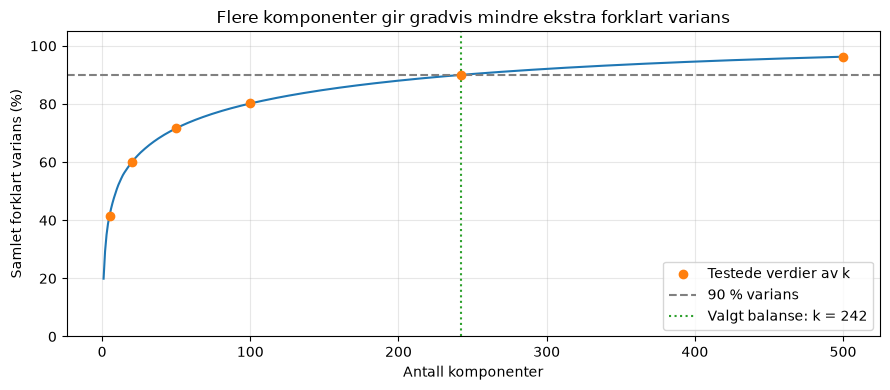

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
component_numbers = np.arange(1, max(k_values) + 1)
ax.plot(component_numbers, experiment_cumulative[:max(k_values)] * 100)
ax.scatter(k_values, experiment_cumulative[np.array(k_values) - 1] * 100,
           color="tab:orange", label="Testede verdier av k", zorder=3)
ax.axhline(variance_target * 100, color="gray", linestyle="--", label="90 % varians")
ax.axvline(k_90, color="tab:green", linestyle=":", label=f"Valgt balanse: k = {k_90}")
ax.set(xlabel="Antall komponenter", ylabel="Samlet forklart varians (%)",
       title="Flere komponenter gir gradvis mindre ekstra forklart varians", ylim=(0, 105))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### Valg av antall komponenter

For dette datasettet velger vi **k = 242** som et kompromiss etter kriteriet om minst 90 % forklart varians. Dette er det minste antallet som oppfyller kriteriet. Til sammenligning forklarer 100 komponenter 80,2 %, mens 500 forklarer 96,3 %. Fra 242 til 500 mer enn dobles antallet komponenter for omtrent 6,3 prosentpoeng ekstra forklart varians. Kurven flater gradvis ut og gir ingen entydig optimal verdi uten et valgt kvalitetskrav.

Hvert bilde representeres da med 242 PCA-verdier i stedet for 4096 pikselverdier. Ved faktisk lagring må også komponentmatrisen og gjennomsnittsbildet lagres, så forholdet 4096/242 er ikke kompresjonsforholdet for hele datasettet eller JPEG-filene.


## Visual Analysis

Vi viser ett bilde fra hver kategori ved siden av rekonstruksjonene med ulike verdier av `k`. Samme bilder og gråtoneskala brukes i alle kolonner. Pikselverdier utenfor [0, 1] begrenses bare ved visning.

Variansprosentene i figuren gjelder hele datasettet, ikke hvert enkelt bilde.


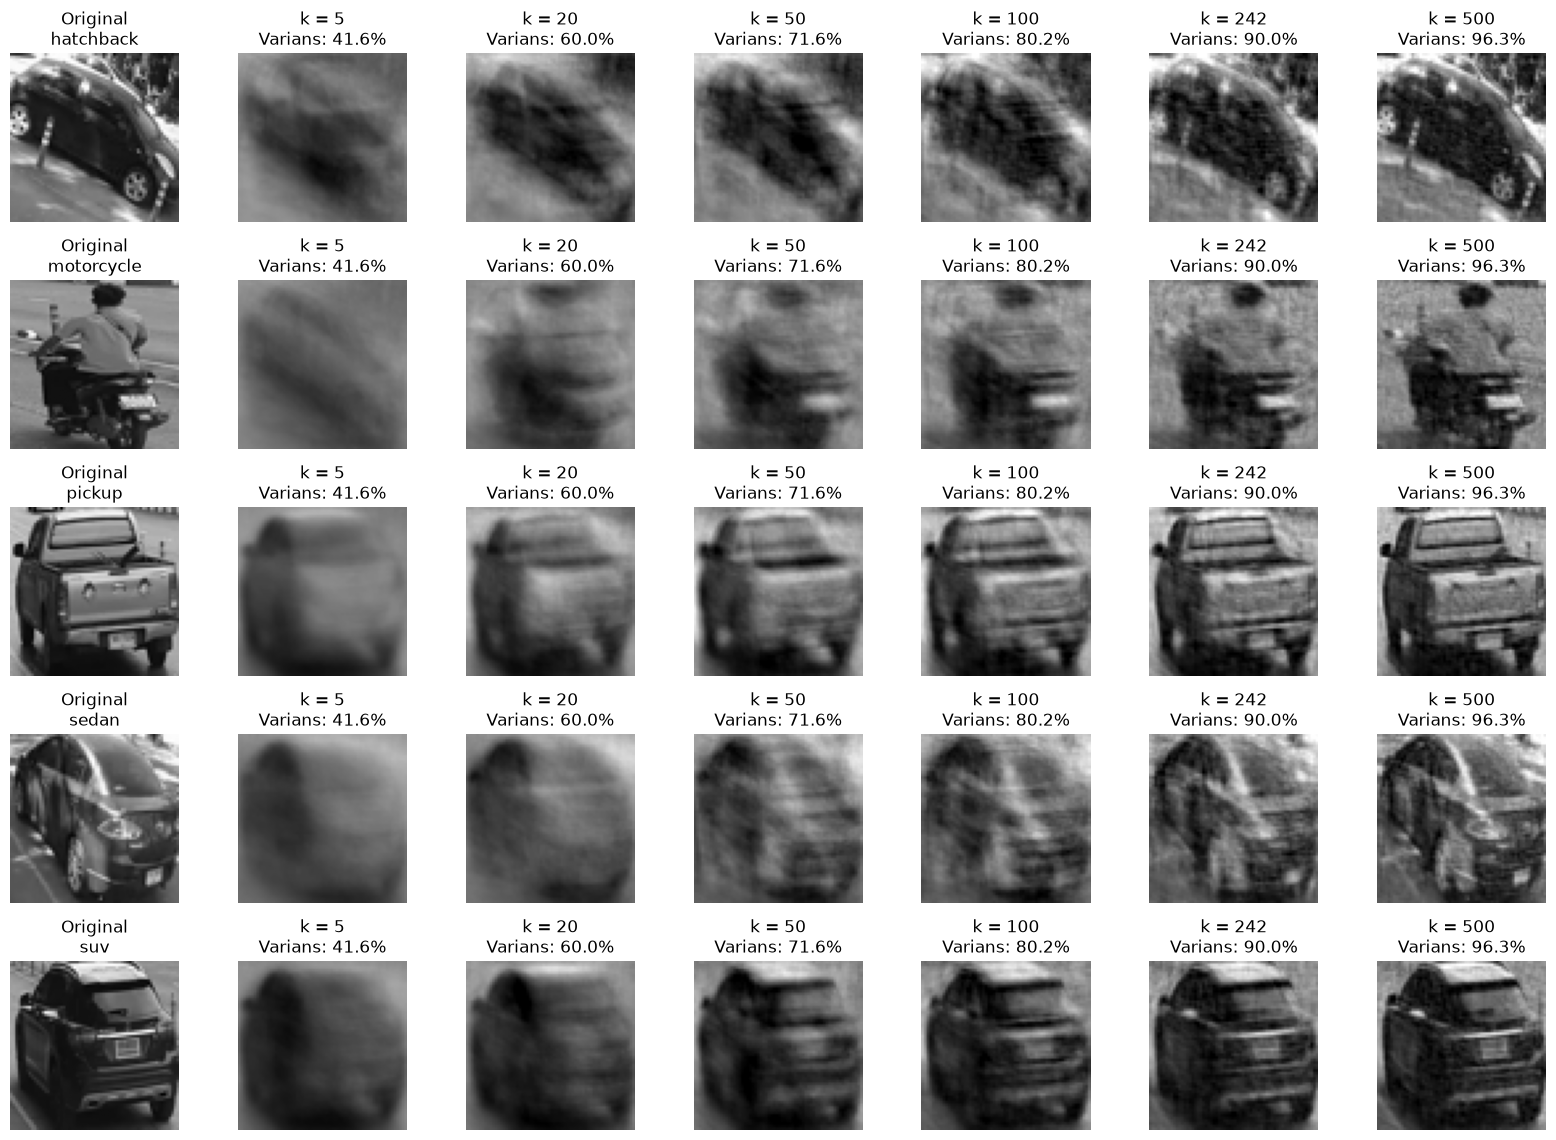

In [28]:
# Samme eksempel fra hver kategori for alle verdier av k.
example_indices = [np.where(labels == label)[0][0] for label in np.unique(labels)]
fig, axes = plt.subplots(len(example_indices), len(k_values) + 1,
                         figsize=(2.3 * (len(k_values) + 1), 2.3 * len(example_indices)),
                         squeeze=False)

for row, index in enumerate(example_indices):
    axes[row, 0].imshow(images[index], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"Original\n{labels[index]}")

for col, n in enumerate(k_values, start=1):
    reconstructed_examples = (
        experiment_scores[example_indices, :n] @ experiment_components[:, :n].T
        + experiment_mean
    ).reshape(len(example_indices), *images.shape[1:])
    for row, image in enumerate(reconstructed_examples):
        axes[row, col].imshow(np.clip(image, 0, 1), cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(f"k = {n}\nVarians: {experiment_cumulative[n - 1]:.1%}")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()


### Visuell vurdering

Med `k = 5` og `k = 20` er bildene svært uskarpe; hovedsakelig grove former og lysforhold beholdes. Ved 50 og 100 komponenter blir kjøretøyene tydeligere, men mange kanter og små detaljer mangler fortsatt. Ved 242 og 500 komponenter ligner rekonstruksjonene mer på originalene, selv om enkelte detaljer fortsatt er utvisket.

PCA-komponentene er beregnet fra de samme bildene som rekonstrueres. Sammenligningen viser derfor rekonstruksjon av dette datasettet, ikke kvaliteten på nye bilder. Eksemplene viser at kvaliteten varierer mellom bilder; MSE kan brukes til å tallfeste forskjellene.


## Error Analysis

MSE (Mean Squared Error) er gjennomsnittet av de kvadrerte forskjellene mellom originale og rekonstruerte pikselverdier:

$$\mathrm{MSE} = 
rac{1}{ND}\sum_{i=1}^{N}\sum_{j=1}^{D}(X_{ij} - \hat{X}_{ij})^2$$

Her er `N` antall bilder og `D` antall piksler per bilde. Lavere MSE betyr mindre rekonstruksjonsfeil; 0 betyr identiske pikselverdier. Vi beregner MSE per bilde og tar deretter gjennomsnittet for hele datasettet. Alle bildene har like mange piksler, s? dette tilsvarer gjennomsnittet over alle pikslene.

Feilen beregnes p? gr?tonebildene i skala [0, 1], f?r rekonstruksjonene begrenses til dette intervallet for visning. Feilen inkluderer ikke informasjon som gikk tapt da originalfilene ble gjort om til gr?toner og 64 ? 64 piksler.

For ? sammenligne lagringsbehov teller vi verdier: originaldataene har `N * D` verdier, mens PCA trenger `N * k` verdier for bildene, `D * k` for komponentene og `D` for gjennomsnittsbildet. Kompresjonsfaktoren er derfor `(N * D) / (N * k + D * k + D)`. Dette forutsetter samme antall byte per verdi. Det er et teoretisk lagringsm?l, ikke en m?ling av JPEG-filer eller faktisk minnebruk med ulike datatyper.


In [29]:
n_images, n_pixels = X.shape
original_values = X.size
mse_per_image = {}
mse_values = []
storage_percent = []
compression_factors = []

for n in k_values:
    reconstructed = (
        experiment_scores[:, :n] @ experiment_components[:, :n].T
        + experiment_mean
    )
    mse_per_image[n] = np.mean((X - reconstructed) ** 2, axis=1)
    mse_values.append(mse_per_image[n].mean())

    stored_values = n_images * n + n_pixels * n + n_pixels
    storage_percent.append(100 * stored_values / original_values)
    compression_factors.append(original_values / stored_values)

print(f"{'k':>5} | {'MSE':>10} | {'Lagring (%)':>12} | {'Kompresjonsfaktor':>18}")
for n, mse, storage, factor in zip(k_values, mse_values, storage_percent, compression_factors):
    print(f"{n:5d} | {mse:10.6f} | {storage:12.1f} | {factor:17.2f}x")


    k |        MSE |  Lagring (%) |  Kompresjonsfaktor
    5 |   0.027834 |          0.6 |            172.39x
   20 |   0.019061 |          2.1 |             47.82x
   50 |   0.013501 |          5.1 |             19.55x
  100 |   0.009437 |         10.2 |              9.85x
  242 |   0.004761 |         24.5 |              4.09x
  500 |   0.001779 |         50.5 |              1.98x


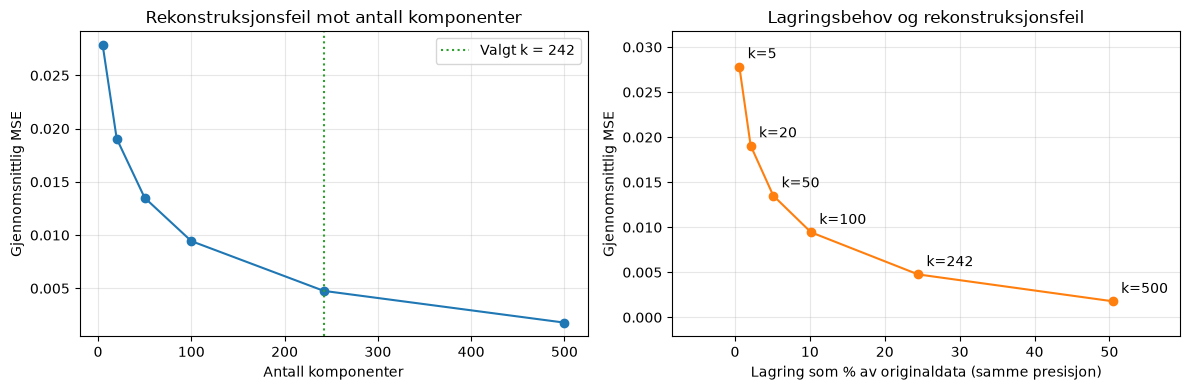

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, mse_values, marker="o")
axes[0].axvline(k_90, color="tab:green", linestyle=":", label=f"Valgt k = {k_90}")
axes[0].set(xlabel="Antall komponenter", ylabel="Gjennomsnittlig MSE",
            title="Rekonstruksjonsfeil mot antall komponenter")
axes[0].legend()

axes[1].plot(storage_percent, mse_values, marker="o", color="tab:orange")
for n, storage, mse in zip(k_values, storage_percent, mse_values):
    axes[1].annotate(f"k={n}", (storage, mse), xytext=(6, 6), textcoords="offset points")
axes[1].set(xlabel="Lagring som % av originaldata (samme presisjon)",
            ylabel="Gjennomsnittlig MSE", title="Lagringsbehov og rekonstruksjonsfeil")
axes[1].margins(x=0.18, y=0.15)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Avveining mellom kompresjon og feil

MSE synker fra **0,027834 ved k = 5** til **0,001779 ved k = 500**. Få komponenter krever lite lagring, men gir stor rekonstruksjonsfeil. Flere komponenter gjenskaper flere detaljer og reduserer feilen, samtidig som både representasjonen av bildene og komponentmatrisen vokser.

Ved vårt valgte **k = 242** er MSE **0,004761**, og den teoretiske lagringen er **24,5 %** av originalmatrisen, inkludert komponentene og gjennomsnittsbildet. Det tilsvarer en kompresjonsfaktor på **4,09** ved samme presisjon per verdi. Til sammenligning gir k = 100 en MSE på 0,009437 med 10,2 % lagring. Ved k = 500 reduseres feilen til 0,001779, men lagringen øker til 50,5 %.

Valget k = 242 er derfor et begrunnet kompromiss under kravet om minst 90 % forklart varians. Hvis liten lagring er viktigst, kan k = 100 være aktuelt; hvis detaljer er viktigere, gir k = 500 lavere feil. MSE alene avgjør ikke hva som ser best ut, så resultatene bør vurderes sammen med bildesammenligningen.

Tallene er gjennomsnitt for hele datasettet; `mse_per_image[n]` inneholder feilene for hvert enkelt bilde ved n komponenter. Vi måler rekonstruksjon på bildene som PCA ble tilpasset til. Resultatene sier derfor ikke hvor godt modellen vil rekonstruere nye bilder.
